# 0 · Los datos y el pipeline

Antes de cualquier modelo: **¿qué son los datos y cómo los procesamos?** Este
notebook carga el panel real y muestra cada paso. Es la base para entender todo lo demás.

**El problema:** detectar **campañas con rinde anómalo** por departamento (soja/maíz,
Argentina, 1981–2024). Es **no supervisado**: entrenamos solo con campañas normales.

In [1]:
import os, explib
os.chdir(explib.ROOT)          # rutas relativas (data/, configs/, runs/) funcionan
import matplotlib.pyplot as plt
import pandas as pd, numpy as np
plt.rcParams['figure.dpi'] = 110

## 1 · El panel
Una fila = un (departamento, campaña, cultivo). Columnas: identificadores, `rinde_kgha`
(el objetivo) y ~54 features climáticas (promedios mensuales Sep–Mar).

In [2]:
from src.config import ExperimentConfig
from src import data as cdata
cfg = ExperimentConfig()
panel = cdata.load_panel(cfg)     # incluye el dedup (ver NB 4)
print("shape:", panel.shape)
panel[["provincia","departamento","campania","cultivo","rinde_kgha"]].head()

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)
shape: (21418, 70)


,provincia,departamento,campania,cultivo,rinde_kgha
0,BUENOS AIRES,25 De Mayo,1981/82,soja,2600.0
1,BUENOS AIRES,9 De Julio,1981/82,soja,1400.0
2,BUENOS AIRES,Alberti,1981/82,soja,1800.0
3,BUENOS AIRES,Arrecifes,1981/82,soja,2207.0
4,BUENOS AIRES,Baradero,1981/82,soja,2000.0


## 2 · La etiqueta proxy `z_rinde`
No tenemos etiquetas de "anomalía". Las definimos: cuánto cae el rinde respecto de la
**media móvil del propio departamento**.

`z_rinde = (rinde − media_móvil) / desvío_móvil`  → `anomalía = z_rinde < −1.5`

Se calcula con `shift(1)` (solo pasado, sin leakage) y agrupando por
`[provincia, departamento, cultivo]`. **El modelo nunca ve esta etiqueta — solo se usa
para evaluar.**

In [3]:
panel_z = cdata.compute_z_rinde(panel, cfg)
print("tasa de anomalías por cultivo:")
print((panel_z.groupby("cultivo")["anomalia"].mean()*100).round(1).astype(str) + " %")

tasa de anomalías por cultivo:
cultivo
maiz    10.8 %
soja    12.9 %
Name: anomalia, dtype: str


### Ejemplo: la serie de rinde de un departamento, con sus anomalías marcadas

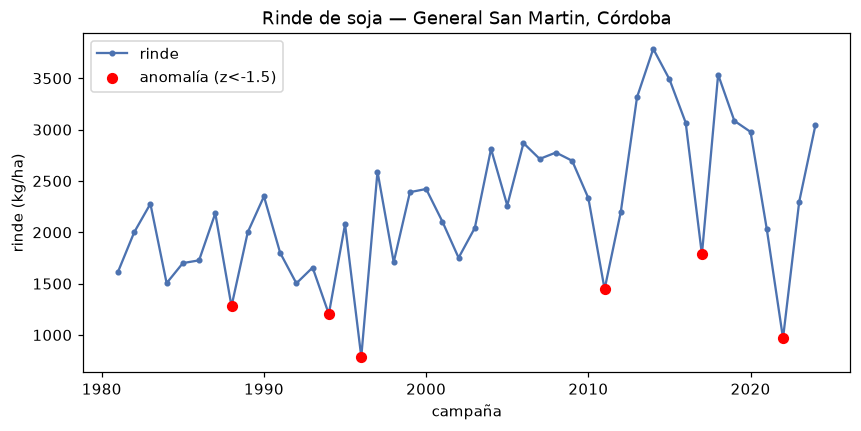

In [4]:
d = panel_z[(panel_z.cultivo=="soja") & (panel_z.provincia=="CORDOBA")]
d = d[d.departamento==d.departamento.value_counts().idxmax()].sort_values("campania_inicio")
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(d.campania_inicio, d.rinde_kgha, "-o", ms=3, color="#4C72B0", label="rinde")
an = d[d.anomalia==1]
ax.scatter(an.campania_inicio, an.rinde_kgha, color="red", zorder=5, s=40, label="anomalía (z<-1.5)")
ax.set_xlabel("campaña"); ax.set_ylabel("rinde (kg/ha)")
ax.set_title(f"Rinde de soja — {d.departamento.iloc[0]}, Córdoba"); ax.legend(); plt.show()

### Distribución de `z_rinde` y el umbral de anomalía

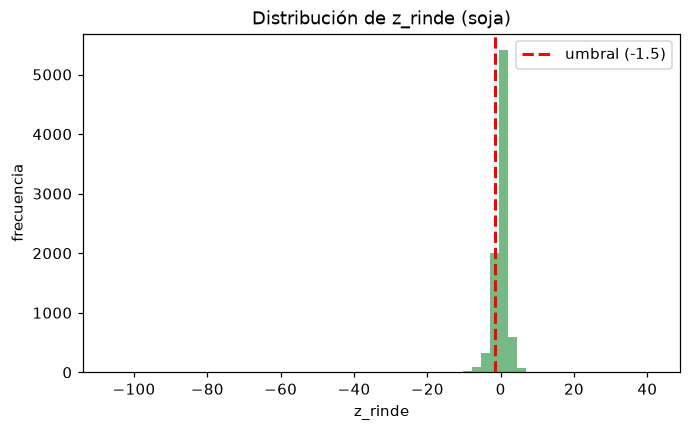

In [5]:
fig, ax = plt.subplots(figsize=(7,4))
ax.hist(panel_z[panel_z.cultivo=="soja"]["z_rinde"].dropna(), bins=60, color="#55A868", alpha=0.8)
ax.axvline(-1.5, color="red", ls="--", lw=2, label="umbral (-1.5)")
ax.set_xlabel("z_rinde"); ax.set_ylabel("frecuencia"); ax.set_title("Distribución de z_rinde (soja)")
ax.legend(); plt.show()

## 3 · Las features (X)
54 columnas = ~9 variables climáticas × 7 meses (Sep–Mar). NO incluyen el rinde.

In [6]:
feats = cdata.build_feature_list(panel, cfg.use_ndvi)
print(f"nº de features: {len(feats)}")
prefijos = sorted(set(f.rsplit('_',1)[0] for f in feats))
print("variables:", prefijos)

nº de features: 54
variables: ['allsky_sfc_sw_dwn', 'oni', 'prectotcorr', 'rh2m', 't2m', 't2m_max', 't2m_min', 'ws2m']


## 4 · Splits temporales + entrenar-solo-con-normales + normalización
- **Split temporal** (no aleatorio): train ≤2017, val 2018–2020, test ≥2021.
- **Train normal**: del train se excluyen las anomalías y los años con >30% de deptos
  anómalos → el modelo aprende solo "lo normal".
- **Normalización por departamento** (z-score), con stats calculadas SOLO en train normal
  (sin leakage), e incluyendo la provincia para no mezclar deptos homónimos.

In [7]:
ds = cdata.build_crop_dataset(panel_z, "soja", cfg)
print(f"train normal (≤2017): {len(ds.X_train):5d} filas")
print(f"val        (2018-20): {len(ds.X_val):5d} filas  ({int(ds.y_val.sum())} anomalías)")
print(f"test       (≥2021)  : {len(ds.X_test):5d} filas  ({int(ds.y_test.sum())} anomalías)")
print(f"X_train: matriz {ds.X_train.shape} (filas normales × features, ya normalizada)")

train normal (≤2017):  5717 filas
val        (2018-20):   704 filas  (44 anomalías)
test       (≥2021)  :   954 filas  (257 anomalías)
X_train: matriz (5717, 54) (filas normales × features, ya normalizada)


**Con esto el pipeline está listo.** Cualquier detector recibe `X_train` (normales)
para `fit()` y puntúa `X_val`/`X_test` con `score_samples()` (mayor = más anómalo). Todo lo
demás (entrenar, evaluar, comparar) se construye sobre esto → próximo notebook.